# Waste Classification Using Convolutional Neural Network

## Project Overview

This project uses a Convolutional Neural Network (CNN) to classify waste images into six categories:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

The project uses the TrashNet dataset and follows a complete image classification pipeline including data preprocessing, online data augmentation, CNN model training, and performance evaluation.

## Objective

The objective of this project is to build a simple CNN-based image classification model that can automatically identify the type of waste present in an image.

## Imports

In [153]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [154]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("Random seeds set successfully.")

Random seeds set successfully.


In [155]:
!wget -O trashnet.zip https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip

--2026-08-13 16:34:36--  https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip
Resolving huggingface.co (huggingface.co)... 3.171.171.65, 3.171.171.128, 3.171.171.6, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.65|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/647949fffaa0a209531b9a2b/154a5f61da453c05242f7483d1ed8c1ccd55a3e81f6072629109f4b5fc891193?response-content-type=application%2Fzip&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27dataset-resized.zip%3B+filename%3D%22dataset-resized.zip%22%3B&user_id=public&Expires=1786642476&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjQ3OTQ5ZmZmYWEwYTIwOTUzMWI5YTJiLzE1NGE1ZjYxZGE0NTNjMDUyNDJmNzQ4M2QxZWQ4YzFjY2Q1NWEzZTgxZjYwNzI2MjkxMDlmNGI1ZmM4OTExOTNcXD9yZXNwb25zZS1jb250ZW50LXR5cGU9KiZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW

In [156]:
!unzip -q trashnet.zip -d trashnet

replace trashnet/dataset-resized/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/__MACOSX/dataset-resized/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard101.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard102.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace trashnet/dataset-resized/cardboard/cardboard103.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [157]:
os.listdir("trashnet")

['dataset-resized', '__MACOSX']

## Dataset Setup

In [158]:
data_dir = "trashnet/dataset-resized"

print("Dataset path:", data_dir)

Dataset path: trashnet/dataset-resized


In [159]:
classes = []

for item in os.listdir(data_dir):
    if os.path.isdir(os.path.join(data_dir, item)):
        classes.append(item)

classes

['plastic', 'cardboard', 'paper', 'metal', 'trash', 'glass']

In [160]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

class_counts

{'plastic': 482,
 'cardboard': 403,
 'paper': 594,
 'metal': 410,
 'trash': 137,
 'glass': 501}

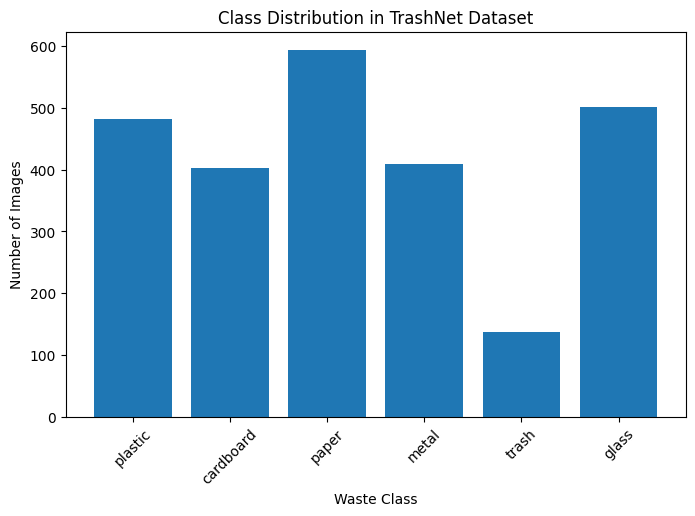

In [161]:
plt.figure(figsize=(8, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in TrashNet Dataset")

plt.xticks(rotation=45)
plt.show()

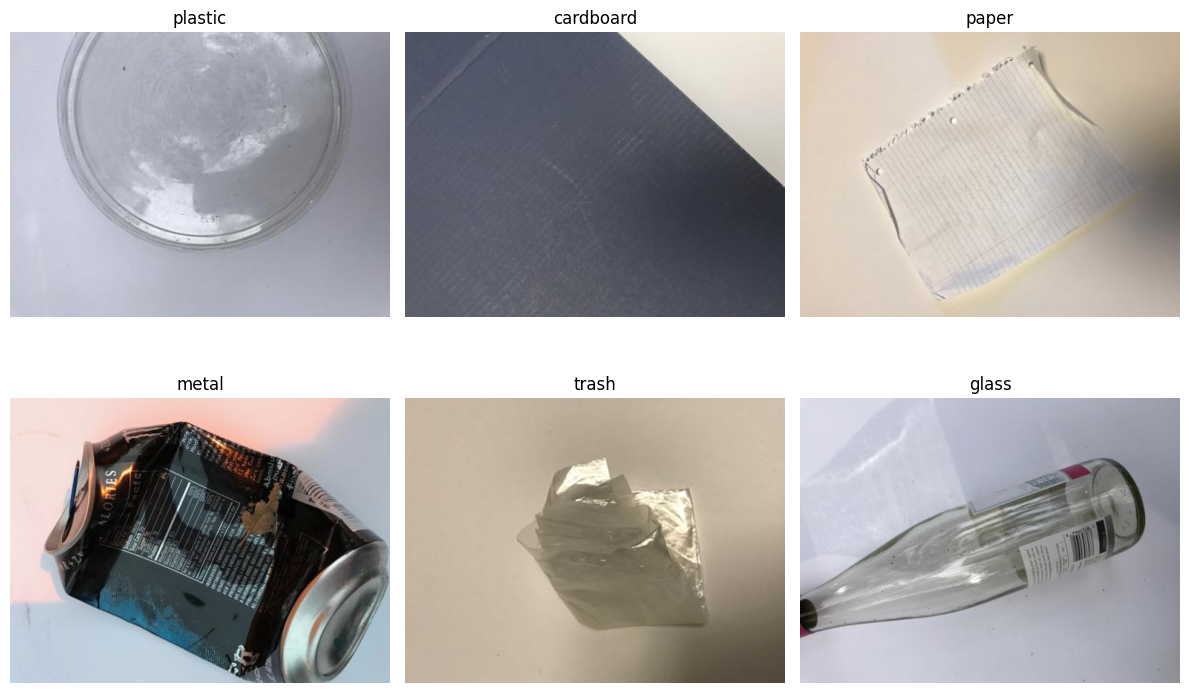

In [162]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [163]:
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print(class_name, ":", image.size)

plastic : (512, 384)
cardboard : (512, 384)
paper : (512, 384)
metal : (512, 384)
trash : (512, 384)
glass : (512, 384)


In [164]:
data = []

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        data.append([image_path, class_name])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total images:", len(df))
df.head()

Total images: 2527


,image_path,label
0,trashnet/dataset-resized/plastic/plastic126.jpg,plastic
1,trashnet/dataset-resized/plastic/plastic295.jpg,plastic
2,trashnet/dataset-resized/plastic/plastic377.jpg,plastic
3,trashnet/dataset-resized/plastic/plastic477.jpg,plastic
4,trashnet/dataset-resized/plastic/plastic292.jpg,plastic


## Dataset Split

In [165]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1768
Validation: 379
Testing: 380


In [166]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTesting distribution:")
print(test_df["label"].value_counts())

Training distribution:
label
paper        416
glass        350
plastic      337
metal        287
cardboard    282
trash         96
Name: count, dtype: int64

Validation distribution:
label
paper        89
glass        75
plastic      72
cardboard    61
metal        61
trash        21
Name: count, dtype: int64

Testing distribution:
label
paper        89
glass        76
plastic      73
metal        62
cardboard    60
trash        20
Name: count, dtype: int64


## Preprocessing

In [167]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (128, 128)
Batch size: 32


In [168]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_index

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [169]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [170]:
def create_dataset(dataframe):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].map(class_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [171]:
train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

print("Train, validation, and test datasets created.")

Train, validation, and test datasets created.


In [172]:
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", images.numpy().min())
print("Pixel maximum:", images.numpy().max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


## Data Augmentation

In [173]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Augmentation layer created successfully.")

Augmentation layer created successfully.


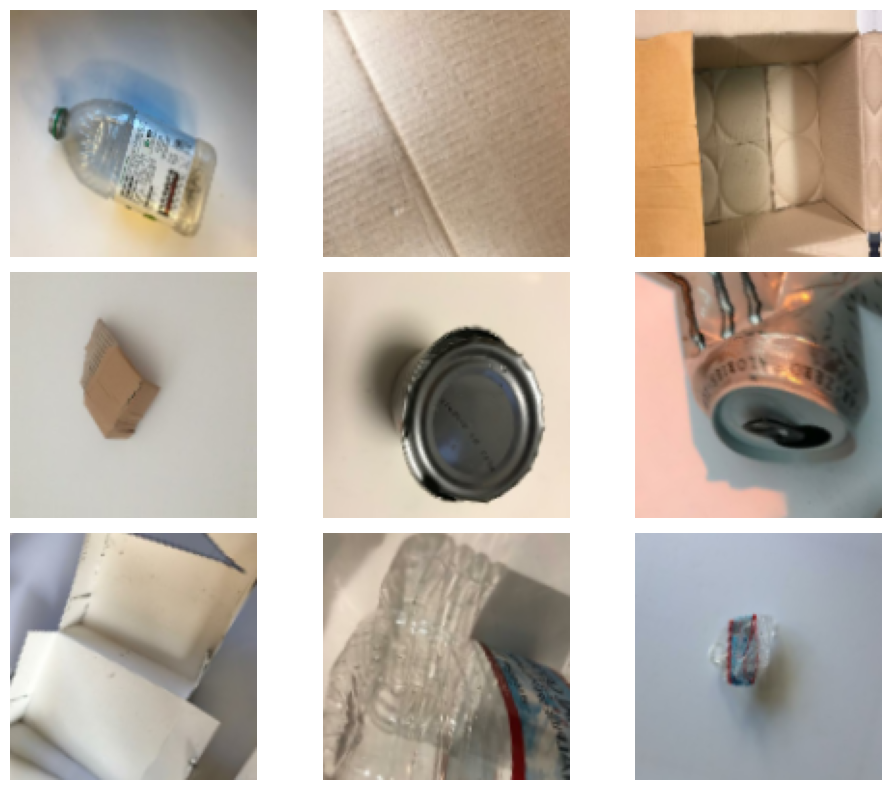

In [174]:
plt.figure(figsize=(10, 8))

for i in range(9):
    # Add batch dimension
    single_image = tf.expand_dims(images[i], axis=0)

    # Apply augmentation
    augmented_image = data_augmentation(
        single_image,
        training=True
    )

    # Remove batch dimension for plotting
    augmented_image = tf.squeeze(augmented_image, axis=0)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image.numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [175]:
test_image = tf.expand_dims(images[0], axis=0)

print("Before augmentation:", test_image.shape)

augmented_test_image = data_augmentation(test_image, training=True)

print("After augmentation:", augmented_test_image.shape)

Before augmentation: (1, 128, 128, 3)
After augmentation: (1, 128, 128, 3)


# Final CNN

In [176]:
model = tf.keras.Sequential([

    # Input layer
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    # Six waste categories
    tf.keras.layers.Dense(6, activation="softmax")
])

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_19 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Architecture

The model consists of three convolutional blocks followed by a fully connected classification layer.

- **Conv2D (32 filters):** extracts basic visual features such as edges and textures.
- **Conv2D (64 filters):** learns more complex visual patterns.
- **Conv2D (128 filters):** captures higher-level features.
- **MaxPooling:** reduces spatial dimensions and computational complexity.
- **Flatten:** converts the extracted feature maps into a one-dimensional vector.
- **Dense (128 units):** learns combinations of the extracted features.
- **Dropout (0.5):** reduces overfitting during training.
- **Softmax output layer:** produces probabilities for the six waste categories.

In [177]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [178]:
images, labels = next(iter(train_dataset))

predictions = model(images, training=False)

print("Input shape:", images.shape)
print("Label shape:", labels.shape)
print("Prediction shape:", predictions.shape)

Input shape: (32, 128, 128, 3)
Label shape: (32,)
Prediction shape: (32, 6)


In [179]:
print("First image probabilities:")
print(predictions[0].numpy())

print("\nSum of probabilities:")
print(tf.reduce_sum(predictions[0]).numpy())

First image probabilities:
[0.17524801 0.15373053 0.18697782 0.14286725 0.17568791 0.16548847]

Sum of probabilities:
1.0


## Model Training

The CNN was trained using the Adam optimizer and sparse categorical cross-entropy loss.

Online data augmentation was applied to the training images to improve generalization.

The model was trained for **40 epochs** with a batch size of **32**.

In [180]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40
)

Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.3026 - loss: 1.6284 - val_accuracy: 0.3958 - val_loss: 1.4714
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4106 - loss: 1.4493 - val_accuracy: 0.4459 - val_loss: 1.3644
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4610 - loss: 1.3438 - val_accuracy: 0.4697 - val_loss: 1.2800
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4904 - loss: 1.2930 - val_accuracy: 0.5092 - val_loss: 1.2023
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5317 - loss: 1.2084 - val_accuracy: 0.5620 - val_loss: 1.1877
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5475 - loss: 1.1651 - val_accuracy: 0.5831 - val_loss: 1.2054
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5441 - loss: 1.1685 - val_accuracy: 0.5673 - val_loss: 1.1169
Epoch 8/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5617 - loss: 1.1398 - val_accuracy: 0.5884 - v

In [181]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = min(history.history["val_loss"])
best_val_accuracy = max(history.history["val_accuracy"])

print("Best epoch based on validation loss:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Best validation accuracy:", best_val_accuracy)

Best epoch based on validation loss: 38
Best validation loss: 0.7991313934326172
Best validation accuracy: 0.7440633177757263


## Training Performance

The training and validation accuracy and loss were monitored across the 40 training epochs.

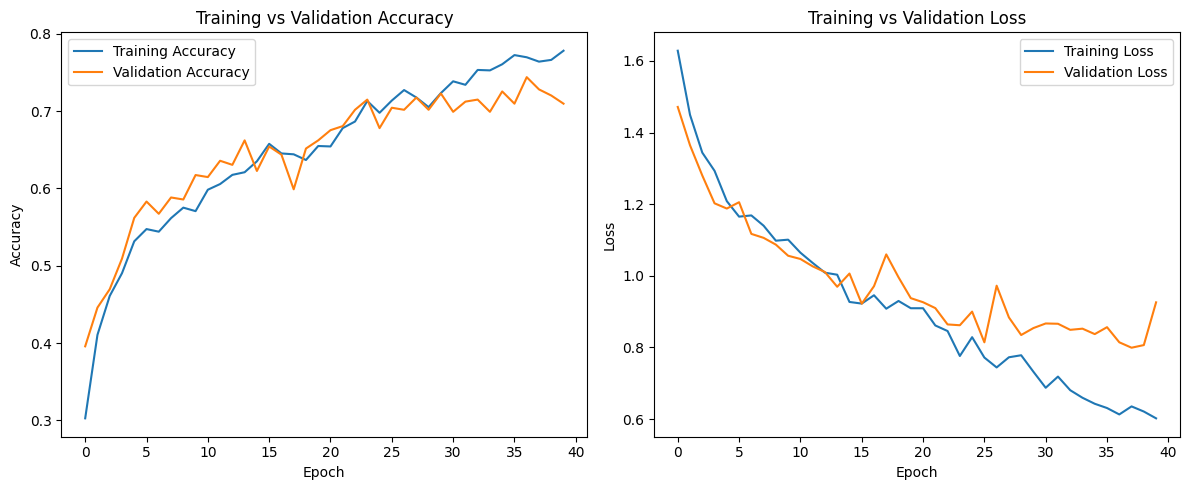

In [182]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Test Set Evaluation

The final model was evaluated on a held-out test set containing **380 images** that were not used during training.

This provides an unbiased estimate of the model's performance on unseen images.

In [183]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7684 - loss: 0.8435
Test Loss: 0.8435197472572327
Test Accuracy: 0.7684210538864136


## Classification Report

The classification report provides precision, recall, and F1-score for each waste category.

In [184]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.94      0.80      0.86        60
       glass       0.74      0.64      0.69        76
       metal       0.78      0.73      0.75        62
       paper       0.81      0.89      0.85        89
     plastic       0.64      0.82      0.72        73
       trash       0.79      0.55      0.65        20

    accuracy                           0.77       380
   macro avg       0.78      0.74      0.75       380
weighted avg       0.78      0.77      0.77       380



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each waste category.

<Figure size 800x800 with 0 Axes>

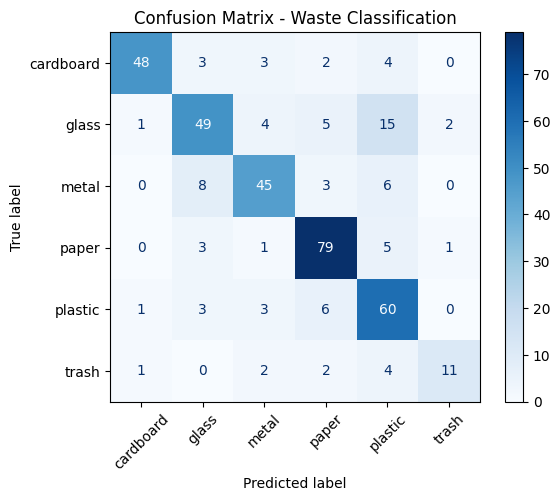

In [185]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Waste Classification")
plt.show()

## Sample Predictions

The following examples show the model's predictions on previously unseen test images.

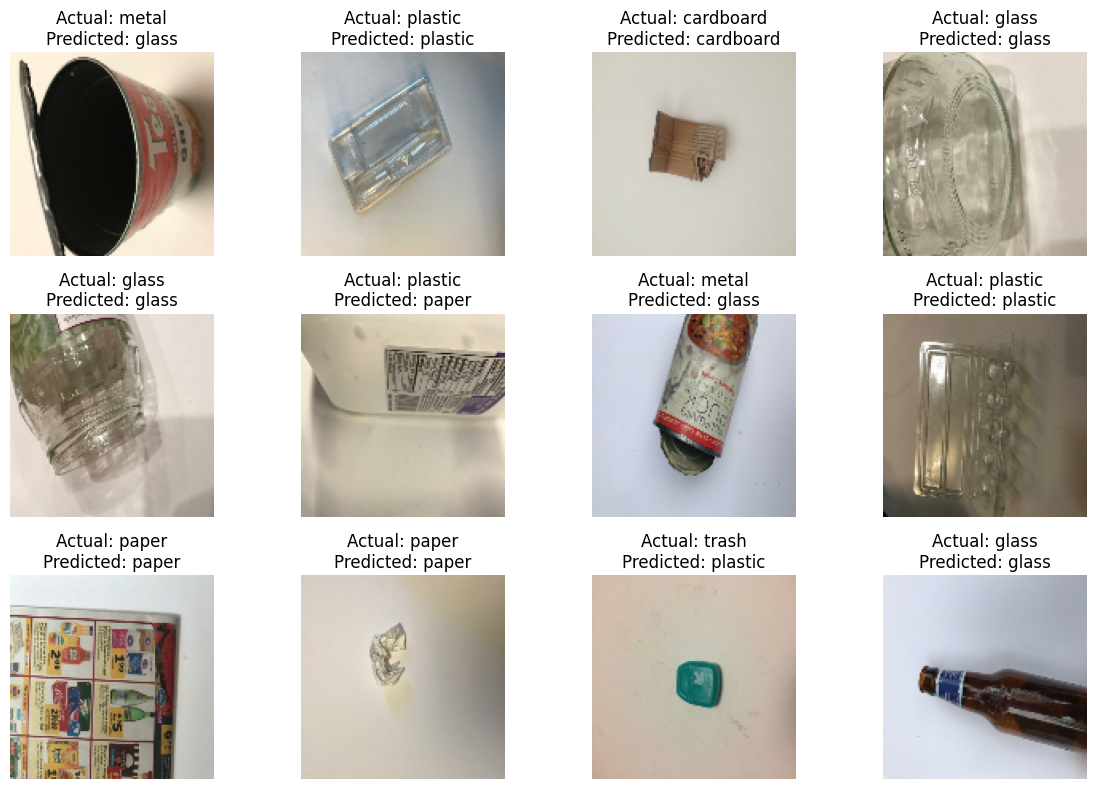

In [186]:
images, labels = next(iter(test_dataset))

predictions = model.predict(images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].numpy())

    actual = class_names[labels[i].numpy()]
    predicted = class_names[predicted_labels[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

A basic Convolutional Neural Network was developed to classify waste images into six categories: cardboard, glass, metal, paper, plastic, and trash.

The model achieved a **test accuracy of 76.84%** on 380 unseen images.

The confusion matrix and classification report showed that the model performed particularly well on paper and cardboard, while glass, metal, and trash were more challenging classes.

This project demonstrates a complete CNN image-classification workflow, including dataset exploration, preprocessing, data augmentation, model training, and evaluation.

In [187]:
model.save("waste_classification_cnn_final.keras")

In [188]:
import os

model_path = "waste_classification_cnn_final.keras"

print("Model saved:", os.path.exists(model_path))
print(
    "Model size:",
    round(os.path.getsize(model_path) / (1024 * 1024), 2),
    "MB"
)

Model saved: True
Model size: 37.88 MB
